Load Libraries and set random seeds

In [11]:
# pandas for data manipulation
# re for regular expressions
import re

# ensure local project packages can be imported (so 'utils' is found)
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# pyplot for plotting
import matplotlib.pyplot as plt

# numpy for numerical operations
import numpy as np
import pandas as pd

# seaborn for advanced plotting
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, make_scorer

# sklearn for machine learning
from sklearn.model_selection import GridSearchCV, train_test_split

# other .py files
from utils.csv_import import get_csv_files_generalistic

# set global numpy seed for reproducibility
np.random.seed(42)


Set maps for CSI data files loading

In [12]:
#path: str = (
#    "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho"
#    "\\tese\\thesis-project\\data"
#    "\\CSI DATA RENAMED [alterado]"
#)

path: str = (
    "C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]"
)

FileMap = dict[str, dict[str, str]]

data_files = get_csv_files_generalistic(path)

Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\00-z00-01-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\00-z00-02-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\00-z00-03-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\00-z00-04-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\01-z00-01-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\01-z00-02-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\01-z00-03-01.csv
Found file: C:\Users\Oscar\Documents\GitHub\thesis-project_isac\data\CSI DATA DM RENAMED [com w00 alterado]\01-z00-04-01.csv


*Define Functions*

Misc

In [13]:
def print_useful_info(file: FileMap) -> None:
	
	# Print information about the files dictionaries
	print("Número de ficheiros recolhidos em ", file, ":", len(file))
	
    # avoid StopIteration if dict is empty
	esp_count = len(next(iter(file.values()))) if file else 0
	print("ESPs por cenário:", esp_count)

	# Print all scenarios names
	print("\nTodos os cenários:", sorted(file.keys()))

	# Count scenarios byW letter prefix
	scenario_prefixes: dict[str, int] = {}
	for scenario in file:
		prefix = scenario[0]
		scenario_prefixes[prefix] = scenario_prefixes.get(prefix, 0) + 1

	print("\nScenarios count by prefix:")
	for prefix, count in sorted(scenario_prefixes.items()):
		print(f"Prefix {prefix}: {count} scenarios")

	print("\n")
	

In [14]:
print_useful_info(data_files)

Número de ficheiros recolhidos em  {'user_0': {'z00': {'esp_1': ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-01-01.csv'], 'esp_2': ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-02-01.csv'], 'esp_3': ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-03-01.csv'], 'esp_4': ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-04-01.csv']}, 'w00': {'esp_1': [], 'esp_2': [], 'esp_3': [], 'esp_4': []}, 'a00': {'esp_1': [], 'esp_2': [], 'esp_3': [], 'esp_4': []}, 'a01': {'esp_1': [], 'esp_2': [], 'esp_3': [], 'esp_4': []}, 'a02': {'esp_1': [], 'esp_2': [], 'esp_3': [], 'esp_4': []}, 'a09': {'esp_1': [], 'esp_2': [], 'esp_3': [], 'esp_4': []}, 'a10': {'esp_1': [], 'esp_2': [], 'esp_3': [], 'esp_4': []}, 'a11': {'esp_1': [], 'esp_2': [], 'esp

In [15]:

# função que processo o arquivo CSV completo
# # e extrai a info da coluna do CSI
# # converte em números complexos
# # calcula a magnitude (2.º passo)
# # 
# e faz ainda uma 1a limpeza
# # remove 2 primeiras subportadoras
# # remove colunas a zero
# # aplica FFT shift

# da tese
# # Vector size verification
# # Subcarrier layout and magnitude computation



csiMap = dict[str, dict[str, np.ndarray]]

def process_csi(file: str):
    df = pd.read_csv(file, header=None)
    csi_col = df.iloc[:, 26]

    valid_csi = []
    for entry in csi_col:
        match = re.search(r'\[(.*?)\]', str(entry))
        if not match:
            continue
        nums = [float(n) for n in re.findall(r'-?\d+', match.group(1))]
        if len(nums) == 128:
            valid_csi.append(nums)

    valid_csi = np.array(valid_csi)
    complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]
    magnitudes = np.abs(complex_csi)

    # Limpeza: remover 2 primeiras subportadoras e colunas todas-zero
    magnitudes = magnitudes[:, 2:]
    magnitudes = magnitudes[:, ~np.all(magnitudes == 0, axis=0)]
    magnitudes = np.fft.fftshift(magnitudes, axes=1)

    return magnitudes

# cria o dict magnitudes
# itera sobre cada posicao da grelha
# # para cada posicao, itera sobre cada esp_id e path
# # devolve o dict magnitudes preenchido
def process_magnitudes(file: FileMap) -> dict[str, dict[str, np.ndarray]]:
    magnitudes: dict[str, dict[str, np.ndarray]] = {}

    # file[user][posicao][esp] -> filepath
    for user_key, positions in file.items():
        for posicao, esps in positions.items():
            if posicao not in magnitudes:
                magnitudes[posicao] = {}

            for esp_id, ficheiro in esps.items():
                if not ficheiro:
                    continue
                print(f"Processing file: {ficheiro} for position {posicao}, esp {esp_id}")
                magnitudes[posicao][esp_id] = process_csi(ficheiro[0])
                print(f"Processed {ficheiro} for position {posicao}, esp {esp_id}")
            
    return magnitudes

# o dict magnitudes fica
# posicao1
# # esp1
# # # array de arrays (cada leitura é um array)
# # ...
# # esp4
# # # array de arrays (cada leitura é um array)


# cálculo das médias das subportadoras

# função que extrai valores de determiada subportadora
# # recolhe apenas uma fracção dos valores (1/6 * nº leituras)
# # e devolve um dicionário com os resultados
# # # dict esp: array de valores
def extrai_valores_sc(magnitudes_dict: csiMap, posicao: str, subcarrier: int, frac: float) -> dict[str, np.ndarray]:
    resultados: dict[str, np.ndarray] = {}
    n: int
    for esp, matriz in magnitudes_dict[posicao].items():
        n = int(matriz.shape[0] * frac)
        resultados[esp] = matriz[:n, subcarrier]

    return resultados

# função que calcula a média dos valores extraídos na função de cima
# retorna um dict com 
# # esp: média
# Nota: np.mean retorna um np.floating; para satisfazer o tipo dict[str, float]
# convertemos explicitamente para float()
def calcular_media_sc(subportadora_dict: dict[str, np.ndarray]) -> dict[str, float]:
    return {esp: float(np.mean(valores)) for esp, valores in subportadora_dict.items()}

# função que calcula a média para cada subportadora
# # para cada sc
# # extrai os (n * frac) primeiros valores de cada esp
# # calcula a sua média 
# # # devolve um dict com
# # # subcarrier: {esp_y: média}
def calcular_medias_para_varias_subportadoras(magnitudes_dict: csiMap, posicao: str, subcarrier_indices: list[int], frac: float) -> dict[int, dict[str, float]]:
    medias_por_subc: dict[int, dict[str, float]] = {}
    for sc in subcarrier_indices:
        valores = extrai_valores_sc(magnitudes_dict, posicao, sc, frac)
        medias = calcular_media_sc(valores)
        medias_por_subc[sc] = medias
    return medias_por_subc


# para cada posição
# # ver o tamanho de cada (auto definido em cima)
# # e para cada subportadora
# # # e para cada esp
# # # # extrair o vetor correto
# # # # guardar no dicionário

dadosMap = dict[int, dict[str, np.ndarray]]

def criar_dataset(posicoes: list[str], magnitudes: csiMap) -> dadosMap:

    subcarriers: list[int] = list(range(51))
    dados: dadosMap = {}
    dados = {sc: {} for sc in subcarriers}
    for posicao in posicoes:
        if posicao not in magnitudes:
            continue
        for sc in subcarriers:
            for esp_id in range(1, 5):
                esp_key = f'esp_{esp_id}'
                # verifica se existe esse esp nessa posicao
                if esp_key not in magnitudes[posicao]:
                    continue
                matriz = magnitudes[posicao][esp_key] 
                # verifica matriz válida e se tem colunas suficientes
                if matriz is None or matriz.size == 0 or sc >= matriz.shape[1]:
                    continue
                vetor = matriz[:, sc].astype(float)
                chave = f"{posicao}_esp_{esp_id}"
                dados[sc][chave] = vetor

    return dados

# Função para normalizar
# a função recebe o dicionário de vetores e o dicionário de médias
# e devolve o dicionário de vetores normalizados
# cada vetor é normalizado subtraindo a média e dividindo pela média
def normalizar_vetores(dados: dadosMap, medias: dict[int, dict[str, float]],posicoes) -> dadosMap:

    subcarriers: list[int] = list(range(51))
    esps_id: list[int] = [1, 2, 3, 4]

    normalizados: dadosMap = {}
    normalizados = {sc: {} for sc in subcarriers}

    for sc in subcarriers:
        for posicao in posicoes:
            for esp_id in esps_id:
                
                chave = f"{posicao}_esp_{esp_id}"
                vetor = dados[sc][chave]

                esp = f"esp_{esp_id}"
                media = medias[sc][esp]

                normalizados[sc][chave] = (vetor - media) / media
    return normalizados

# Função para normalizar dados a afinar
def normalizar_vetores_afinar(vetores: dadosMap, medias: dict[int, dict[str, float]]) -> dadosMap:

    subcarriers: list[int] = list(range(51))
    esps_id: list[int] = [1, 2, 3, 4]
    
    normalizados: dadosMap = {}
    normalizados = {sc: {} for sc in subcarriers}

    for sc in subcarriers:
        for posicao in posicoes_afinar:
            for esp_id in esps_id:

                chave = f"{posicao}_esp_{esp_id}"
                vetor = vetores[sc][chave]
                
                esp = f"esp_{esp_id}"
                media = medias[sc][esp]

                normalizados[sc][chave] = (vetor - media) / media
    return normalizados


# função para calcular a média em janelas sobrepostas
def media_grupos_overlap(vetor: np.ndarray, tamanho_janela: int, step: int) -> np.ndarray:
    medias: list[float] = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        medias.append(float(np.mean(janela)))
    return np.array(medias)

# função para calcular o desvio padrão em janelas sobrepostas
def std_grupos_overlap(vetor: np.ndarray, tamanho_janela: int, step: int) -> np.ndarray:
    desvios: list[float] = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        desvios.append(float(np.std(janela)))
    return np.array(desvios)

# função para calcular o máximo em janelas sobrepostas,
# evitando repetições dos últimos 3 máximos escolhidos
def max_grupos_overlap(vetor: np.ndarray, tamanho_janela: int, step: int) -> np.ndarray:
    maximos: list[float] = []
    for i in range(0, len(vetor) - tamanho_janela + 1, step):
        janela = vetor[i:i + tamanho_janela]
        candidatos = np.sort(np.unique(janela))[::-1]  # do maior para o menor

        # Exclui os 3 últimos valores
        ultimos = set(maximos[-3:])

        escolhido = None
        for val in candidatos:
            if val not in ultimos:
                escolhido = val
                break

        # Se todos os valores estão nos últimos 3, aceita o maior mesmo assim
        if escolhido is None:
            escolhido = candidatos[0]

        maximos.append(escolhido)

    return np.array(maximos)

def media_fixed(vetor: np.ndarray, tamanho_janela: int, W: int) -> np.ndarray:
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return media_grupos_overlap(vetor, tamanho_janela, step)[:W]

def std_fixed(vetor: np.ndarray, tamanho_janela: int, W: int) -> np.ndarray:
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return std_grupos_overlap(vetor, tamanho_janela, step)[:W]

def max_fixed(vetor: np.ndarray, tamanho_janela: int, W: int) -> np.ndarray:
    step = (len(vetor) - tamanho_janela) // (W - 1)
    return max_grupos_overlap(vetor, tamanho_janela, step)[:W]

CSI Load and Pre-processing

In [ ]:
magnitudes: csiMap = {}
magnitudes = process_magnitudes(data_files)


# posição para retirar normalizações - escolha ARBITRÁRIA (explorar outras opções?)
posicao: str = 'c06'

# inicializa lista de subportadoras e números de ESPs
subcarriers: list[int] = list(range(51))
esps_id: list[int] = [1, 2, 3, 4]

# fração dos valores a considerar
frac: float = 1/6

medias: dict[int, dict[str, float]] = {}
medias = calcular_medias_para_varias_subportadoras(magnitudes, posicao, subcarriers, frac)



Processing file: ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-01-01.csv'] for position z00, esp esp_1
Processed ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-01-01.csv'] for position z00, esp esp_1
Processing file: ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-02-01.csv'] for position z00, esp esp_2
Processed ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-02-01.csv'] for position z00, esp esp_2
Processing file: ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-03-01.csv'] for position z00, esp esp_3
Processed ['C:\\Users\\Oscar\\Documents\\GitHub\\thesis-project_isac\\data\\CSI DATA DM RENAMED [com w00 alterado]\\00-z00-03-01.csv'] for position z00, esp esp_3
P

In [ ]:
# Célula para codigo de testes / debug 
print(medias)
print(medias.keys())

print(magnitudes.keys())


{0: {'esp_1': 19.783284348515192, 'esp_2': 11.852946292126166, 'esp_3': 19.043563130885143, 'esp_4': 18.124720019166087}, 1: {'esp_1': 18.765218641963873, 'esp_2': 12.217484862063944, 'esp_3': 18.03262675591643, 'esp_4': 17.177832606641445}, 2: {'esp_1': 17.538002255685292, 'esp_2': 13.028075004236296, 'esp_3': 18.562876701179263, 'esp_4': 17.44571081929936}, 3: {'esp_1': 16.95291564671935, 'esp_2': 14.192170674404512, 'esp_3': 18.579805108635902, 'esp_4': 17.577473126818212}, 4: {'esp_1': 16.412739791790692, 'esp_2': 15.384548528913673, 'esp_3': 18.647664526171187, 'esp_4': 17.578269777625064}, 5: {'esp_1': 16.626172228362492, 'esp_2': 16.87285001783515, 'esp_3': 17.213007292963844, 'esp_4': 18.42993894151038}, 6: {'esp_1': 18.211508742173844, 'esp_2': 18.40497073889984, 'esp_3': 17.844184116047956, 'esp_4': 18.844069804909424}, 7: {'esp_1': 20.115085357917017, 'esp_2': 19.956615259934573, 'esp_3': 17.647156869324725, 'esp_4': 19.31851681070694}, 8: {'esp_1': 21.758589525613043, 'esp_

In [31]:
posicoes: list[str] = []
posicoes_afinar: list[str] = []

posicoes = ["z00", "w00", "a00", "a01", "a02", "a09", "a10",
        "a11", "b00", "b01", "b02", "b03", "b04", "b05", "b06",
        "b07", "b08", "b09", "b10", "b11", "c01", "c02", "c03",
        "c04", "c05", "c06", "c07", "c08", "c09", "c10", "c11",
        "d01", "d02", "d03", "d04", "d05", "d06", "d07", "d08",
        "d09", "d10", "d11", "e04", "e05", "e06",]

dados: dadosMap = {}
dados = criar_dataset(posicoes, magnitudes)

dados_normalizados: dadosMap = {}
dados_normalizados = normalizar_vetores(dados, medias, posicoes)


In [ ]:
# Célula para codigo de testes / debug 
print(dados.keys())
print(dados)

print(dados_normalizados.keys())
print(dados_normalizados)

In [ ]:
# Célula para codigo de testes / debug 
print(dados_normalizados[0]["z00_esp_1"].shape)
print(dados_normalizados[0]["a00_esp_1"].shape)
print(dados_normalizados[32]["b00_esp_1"].shape)

(185,)
(76,)
(79,)


Cálculo de médias

In [36]:
subcarriers: list[int] = list(range(51))
tamanho_janela: int = 10
step: int = 3
W: int = 27 # Este valor precisa de ser estudado e ajustado consoante o tamanho dos vetores ?
G: int = 60 # Para vazio

medias_dados: dadosMap = {sc: {} for sc in subcarriers}
stds_dados: dadosMap = {sc: {} for sc in subcarriers}
maxs_dados: dadosMap = {sc: {} for sc in subcarriers}

for pos in posicoes:
    for esp_id in esps_id:
        chave = f"{pos}_esp_{esp_id}"
        for sc in subcarriers:
            vetor = dados_normalizados[sc][chave]

            if pos == 'z00':
                media_1 = media_grupos_overlap(vetor, tamanho_janela, W)
                std_1 = std_grupos_overlap(vetor, tamanho_janela, W)
                max_1 = max_grupos_overlap(vetor, tamanho_janela, W)

            else:
                media1 = media_fixed(vetor, tamanho_janela, W)
                std1 = std_fixed(vetor, tamanho_janela, W)
                max1 = max_fixed(vetor, tamanho_janela, W)

            medias_dados[sc][chave] = media_1
            stds_dados[sc][chave] = std_1
            maxs_dados[sc][chave] = max_1



In [38]:
# Célula para codigo de testes / debug 
print(medias_dados.keys())
print(medias_dados)

print(stds_dados.keys())
print(stds_dados)

print(maxs_dados.keys())
print(maxs_dados)

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])
{0: {'z00_esp_1': array([ 0.09741191,  0.113409  ,  0.01660893, -0.0542989 ,  0.04580223,
       -0.02719293,  0.02960833]), 'z00_esp_2': array([ 0.01067735,  0.29488384, -0.32363525, -0.18479226, -0.09606183,
       -0.22268435, -0.23589451,  0.0574837 ]), 'z00_esp_3': array([-0.082842  , -0.02884495, -0.0434615 , -0.10415173,  0.00031925,
       -0.1058457 , -0.07505859, -0.21006242]), 'z00_esp_4': array([-0.23616918, -0.27425832, -0.08020588, -0.17636868, -0.06792479,
       -0.21638505, -0.29551788, -0.2304143 ,  0.02477532,  0.02170665]), 'w00_esp_1': array([-0.18897149, -0.23829522, -0.0876823 , -0.14373906, -0.07591541,
       -0.19062275, -0.26172282, -0.19224155,  0.02740735,  0.02290574]), 'w00_esp_2': array([-0.18897149, -0.23829522, -0.0876823 , -0.14373906, -0.07591541,


Célula a baixo ainda não está a funcionar

In [23]:
# Deal with class imbalanceo of the dataset before doing a train/test split by undersampling the majority class while preserving the same ammount of samples from different positions and ESPs

# First count the number of samples in each position per ESP class
from traitlets import List

position_esp_counts: dict[str, int] = {}
for pos in posicoes:
    for esp_id in esps_id:
        key = f"{pos}_esp_{esp_id}"
        count = len(medias_dados[22][key])  # usando subportadora 22 como referência
        position_esp_counts[key] = count

# Now sum counts per position across ESPs
position_counts: dict[str, int] = {}
for pos in posicoes:
    total_count = sum(position_esp_counts[f"{pos}_esp_{esp_id}"] for esp_id in esps_id)
    position_counts[pos] = total_count

# Find the minimum count among all positions per ESP (excluding the 'z00')
min_count: int = min(count for pos, count in position_esp_counts.items() if pos != 'z00')

# Find the number of samples that each class can have after undersampling to match z00
n_samples_per_class: int = position_counts['z00'] // (len(posicoes) - 1)

# Random sample from each position per ESP to match the undersampled size or the minimum count
selected_indices: List[int] = []    
current_index: int = 0

for pos in posicoes:
    for esp_id in esps_id:
        key = f"{pos}_esp_{esp_id}"
        count = position_esp_counts[key]

        if pos == 'z00':
            continue  # skip z00

        else:
            if len(medias_dados[22][key]) > min_count:
                n_to_sample = n_samples_per_class // 4  # divide by number of ESPs
            else:
                n_to_sample = min_count

        indices = list(range(current_index, current_index + count))
        sampled_indices = np.random.choice(indices, size=n_to_sample, replace=False)
        selected_indices.extend(sampled_indices)

        current_index += count

# Create the new dictionary with undersampled data
medias_dados_undersampled: dadosMap = {sc: {} for sc in subcarriers}
svd_dados_undersampled: dadosMap = {sc: {} for sc in subcarriers}
maxs_dados_undersampled: dadosMap = {sc: {} for sc in subcarriers}

for sc in subcarriers:
    for pos in posicoes:
        for esp_id in esps_id:
            chave = f"{pos}_esp_{esp_id}"
            vetor_media = medias_dados[sc][chave]
            vetor_std = stds_dados[sc][chave]
            vetor_max = maxs_dados[sc][chave]

            medias_dados_undersampled[sc][chave] = vetor_media[np.isin(
                np.arange(len(vetor_media)), selected_indices)]
            svd_dados_undersampled[sc][chave] = vetor_std[np.isin(
                np.arange(len(vetor_std)), selected_indices)]
            maxs_dados_undersampled[sc][chave] = vetor_max[np.isin(
                np.arange(len(vetor_max)), selected_indices)]

medias_dados = medias_dados_undersampled
stds_dados = svd_dados_undersampled
maxs_dados = maxs_dados_undersampled



In [39]:
subcarriers_map: dict[int, str] = {i + 1: sc for i, sc in enumerate(subcarriers)}

# dicionarios para colunas
coluna_media: dict[str, np.ndarray] = {}
coluna_std: dict[str, np.ndarray] = {}
coluna_max: dict[str, np.ndarray] = {}

for sc_label, sc in subcarriers_map.items():
    for esp_id in esps_id:
        # nome da coluna
        name_mean = f"sc_{sc_label}_esp_{esp_id}_mean"
        name_std = f"sc_{sc_label}_esp_{esp_id}_std"
        name_max = f"sc_{sc_label}_esp_{esp_id}_max"

        sequencia_mean, sequencia_std, sequencia_max = [], [], []

        for pos in posicoes:
            key = f"{pos}_esp_{esp_id}"

            sequencia_mean.append(medias_dados[sc][key])
            sequencia_std.append(stds_dados[sc][key])
            sequencia_max.append(maxs_dados[sc][key])

        # Concatena as colunas 
        coluna_media[name_mean] = np.concatenate(sequencia_mean)
        coluna_std[name_std] = np.concatenate(sequencia_std)
        coluna_max[name_max] = np.concatenate(sequencia_max)


In [40]:
all_cols: dict[str, np.ndarray] = {**coluna_media, **coluna_std, **coluna_max}
min_len: int = min(len(v) for v in all_cols.values())   

# trunca todas as colunas para min_len
coluna_media = {k: v[:min_len] for k, v in coluna_media.items()}
coluna_std = {k: v[:min_len] for k, v in coluna_std.items()}
coluna_max = {k: v[:min_len] for k, v in coluna_max.items()}

# gerar um vetor de labels -  0 = vazio, 1 = pessoa presente
# numero de zeros é o numero de leituras na posicao z00
n_zero: int = sum([len(medias_dados[22][f"z00_esp_{esp_id}"]) for esp_id in esps_id])

# numero total de leituras depois de truncado é min_len
n_total: int = min_len

# Criar vetor de labels
labels: np.ndarray = np.zeros(n_total, dtype=int)
labels[n_zero:] = 1  # definir os restantes como 1 (pessoa presente)

# criar DataFrame final
df: pd.DataFrame = pd.DataFrame({**coluna_media, **coluna_std, **coluna_max})
df['label'] = labels

# To check:
print("DataFrame shape:", df.shape)
print(df.shape)
df.describe()

DataFrame shape: (447, 613)
(447, 613)


,sc_1_esp_1_mean,sc_1_esp_2_mean,sc_1_esp_3_mean,sc_1_esp_4_mean,sc_2_esp_1_mean,sc_2_esp_2_mean,sc_2_esp_3_mean,sc_2_esp_4_mean,sc_3_esp_1_mean,sc_3_esp_2_mean,...,sc_49_esp_4_max,sc_50_esp_1_max,sc_50_esp_2_max,sc_50_esp_3_max,sc_50_esp_4_max,sc_51_esp_1_max,sc_51_esp_2_max,sc_51_esp_3_max,sc_51_esp_4_max,label
count,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,...,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000,447.000000
mean,-0.130312,-0.132424,-0.132312,-0.133914,-0.130061,-0.132601,-0.132441,-0.133639,-0.130112,-0.132273,...,0.102775,0.093820,0.089828,0.095774,0.101277,0.094501,0.099429,0.092665,0.091255,0.926174
std,0.098241,0.098989,0.096127,0.096729,0.098526,0.097461,0.095811,0.097666,0.098437,0.096874,...,0.093487,0.055134,0.048911,0.058291,0.084794,0.053355,0.101824,0.050418,0.047770,0.261780
min,-0.261723,-0.323635,-0.261723,-0.295518,-0.261723,-0.282607,-0.261723,-0.310836,-0.261723,-0.261723,...,-0.005710,-0.005710,-0.046525,-0.005710,-0.005710,-0.005710,-0.005710,-0.111094,-0.005710,0.000000
25%,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,-0.192242,...,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,0.059460,1.000000
50%,-0.143739,-0.184792,-0.143739,-0.188971,-0.143739,-0.187340,-0.143739,-0.188971,-0.143739,-0.143739,...,0.108567,0.108567,0.104444,0.108567,0.108567,0.108567,0.108567,0.108567,0.104444,1.000000
75%,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,-0.075915,...,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,0.135676,1.000000
max,0.113409,0.294884,0.027407,0.027407,0.112641,0.097627,0.027407,0.097685,0.089733,0.076464,...,0.720773,0.616466,0.158219,0.428526,0.687121,0.353530,1.755969,0.241347,0.158219,1.000000


In [41]:
# X e Y - features e labels
# Divisão de treino e teste com rácio 80-20
X: np.ndarray = df.drop(columns='label').values
Y: np.ndarray = df['label'].values

# --- IGNORE ---
print(("X shape:", X.shape))
print(("Y shape:", Y.shape))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(("X_train shape:", X_train.shape))
print(("Y_train shape:", Y_train.shape))
print(("X_test shape:", X_test.shape))
print(("Y_test shape:", Y_test.shape))

('X shape:', (447, 612))
('Y shape:', (447,))
('X_train shape:', (357, 612))
('Y_train shape:', (357,))
('X_test shape:', (90, 612))
('Y_test shape:', (90,))


#### Random Forest Classifier

In [42]:
model = RandomForestClassifier(min_samples_split=4,
                                min_samples_leaf=4,
                                max_leaf_nodes=64,
                                n_estimators=150,
                                random_state = 200,
                                max_depth=16,
                                class_weight="balanced_subsample",
                                criterion='entropy'
)

model = model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

# Note that while balanced_accuracy_score is used, if the dataset is imbalanced training could be affected.
ball_acc = balanced_accuracy_score(Y_test, y_pred)
print("Balanced Accuracy:", ball_acc)

Balanced Accuracy: 0.6428571428571428


In [43]:
confusion_matrix_test = confusion_matrix(Y_test, y_pred)

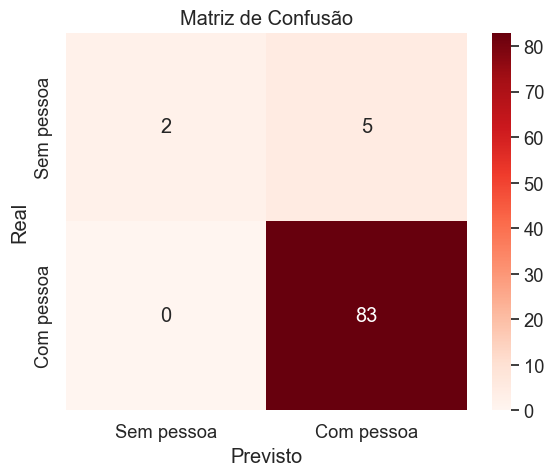

In [44]:
sns.set(font_scale=1.2)
plt.figure(figsize=(6, 5))

sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Reds',
            xticklabels=["Sem pessoa", "Com pessoa"],
            yticklabels=["Sem pessoa", "Com pessoa"])

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [45]:
# Grid Search 
# 432 combinações
param_grid = {
    'min_samples_split': [4, 16, 32],
    'min_samples_leaf': [4, 16, 32, 64],
    'max_leaf_nodes': [4, 16, 32, 64],
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 16, 32]
}

rf = RandomForestClassifier(
    random_state=200,
    class_weight="balanced_subsample",
    criterion='entropy'
)

scorer = make_scorer(balanced_accuracy_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=2
)

# fit
grid_search.fit(X_train, Y_train)

# Best model and parameters
print("Best balanced accuracy:", grid_search.best_score_)
print("Best params:", grid_search.best_params_)

# Predict with best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test balanced accuracy:", balanced_accuracy_score(Y_test, y_pred))

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best balanced accuracy: 0.6242424242424243
Best params: {'max_depth': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 100}
Test balanced accuracy: 0.6428571428571428
